## **0. Initialization**

### **Installation**
LoopDetectR is on CRAN and can be installed within R by

In [1]:
# Before running the R code cells in jupyter notebook,
# initialize the R kernel by this line of code:
# IRkernel::installspec()

In [2]:
# Download and install
install.packages("LoopDetectR")

Installing package into 'C:/Users/Admin/AppData/Local/R/win-library/4.5'
(as 'lib' is unspecified)



package 'LoopDetectR' successfully unpacked and MD5 sums checked

The downloaded binary packages are in
	C:\Users\Admin\AppData\Local\Temp\Rtmpk1kCL5\downloaded_packages


In [3]:
install.packages("deSolve")  # if not already installed
install.packages("numDeriv") # if not already installed

Installing package into 'C:/Users/Admin/AppData/Local/R/win-library/4.5'
(as 'lib' is unspecified)



package 'deSolve' successfully unpacked and MD5 sums checked

The downloaded binary packages are in
	C:\Users\Admin\AppData\Local\Temp\Rtmpk1kCL5\downloaded_packages


Installing package into 'C:/Users/Admin/AppData/Local/R/win-library/4.5'
(as 'lib' is unspecified)



package 'numDeriv' successfully unpacked and MD5 sums checked

The downloaded binary packages are in
	C:\Users\Admin\AppData\Local\Temp\Rtmpk1kCL5\downloaded_packages


In [1]:
# Load package
library("LoopDetectR")
library(deSolve)
library(tidyverse)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.1     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.2.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [2]:
colors <- c('#EE7733', '#0077BB', '#33BBEE', '#EE3377', '#CC3311', '#009988', '#BBBBBB')

## **1. Model definition**

Model POSm4 with 4 positive feedbacks can be loaded from the library

In [34]:
# Load example ODE system with function func_POSm4, 4 variables
data("func_POSm4")

## **2. Result reproduction**

### **2.1. Loop structures**

In [35]:
# Parameters from supplementary material
klin <- c(150, 0.04, 0.3, 500, 5000, 80, 4, 5)
knonlin <- c(0.3,2)
s_star <- c(1,2,3,4) # Dummy steady state for initialization

# Parameters not yet in supplement data
perturbation_point <- 8.6

In [36]:
# compute loops
res_tab <- find_loops_vset(func_POSm4,vset=list(s_star),t=1,klin=klin,
                           knonlin=knonlin,max_num_loops=10)
# The loop list is reported
res_tab$loop_rep[[1]] 
# To access a specific loop representation: e.g., the sixth loop, add [6,]

loop,length,sign
<I<list>>,<dbl>,<dbl>
"1, 1",1,-1
"2, 2",1,-1
"3, 3",1,-1
"4, 4",1,-1
"3, 4, 1,....",4,-1
"3, 4, 2, 3",3,1


In [37]:
loop_summary(res_tab$loop_rep[[1]])

,len_1,len_2,len_3,len_4
,<dbl>,<dbl>,<dbl>,<dbl>
all,4,0,1,1
pos,0,0,1,0
neg,4,0,0,1


In [38]:
# Index of node of interest
noi <- 2
# Return all loops from loop_list containing node 2
loop_list <- res_tab$loop_rep[[1]]
loop_list[vapply(loop_list$loop,function(x){noi %in% x},logical(1)),]

,loop,length,sign
,<I<list>>,<dbl>,<dbl>
2,"2, 2",1,-1
5,"3, 4, 1,....",4,-1
6,"3, 4, 2, 3",3,1


### **2.2. Calculating the Jacobian matrix**

Sign jacobian matrix can be access via `res_tab` variable that we have calculated above, or derived from a jacobian matrix at a specific state

In [39]:
# The corresponding signed Jacobian matrix
res_tab$jac_rep[[1]]

-1,0,0,-1
1,-1,0,1
0,1,-1,0
0,0,1,-1


The function jacobian from the numDeriv package can be used to determine numerically the Jacobian matrix of an ODE system at a certain set of values for the variables, `s_star`. The approach is that of finite differences (with real step) or complex step approach, the latter of which is supposed to deliver more exact results [Martins et al., 2003].

The input function, in the example `func_POSm4` (positive feedback chain model from [Baum et al., 2016]) defines the time derivatives of the modelled variables as a vector: 
$f_i(s)=dS_i/dt$. Note that only those input arguments to the function that encode the modelled variables (and hence in whose direction the partial derivatives are taken) are allowed to be called `x`.

In [40]:
# The function func_POSm4 returns a vector, but deSolve needs the vector within
# a list as output. Therefore, we define a function that simply puts the output 
# of func_POSm4 into a list:
func_POSm4_list <- function(t,x,klin,knonlin){list(func_POSm4(t,x,klin,knonlin))}
sol <-  deSolve::ode(y = rep(1,4), times = seq(0,11,0.1), func = func_POSm4_list, 
                     parms=klin, knonlin=knonlin)

# Set the last point of the numeric solution as point of interest, omit the 
# first column (it contains the time)
s_star <- sol[dim(sol)[1],2:dim(sol)[2]]
s_star

1            2            3            4 
2.592431e+02 3.714482e-03 2.183016e-02 2.955481e-01

In [41]:
j_matrix <- numDeriv::jacobian(func_POSm4,s_star,method="complex",
                               t=1,klin=klin,knonlin=knonlin,)
j_matrix

-0.37882163,0,0,-68.1056
0.07882163,-5500,0,68.1056
0.00000000,500,-84,0.0000
0.00000000,0,80,-5.0000


In [42]:
signed_jacobian <- sign(j_matrix)
signed_jacobian

-1,0,0,-1
1,-1,0,1
0,1,-1,0
0,0,1,-1


### **2.3. Temporal dynamics**

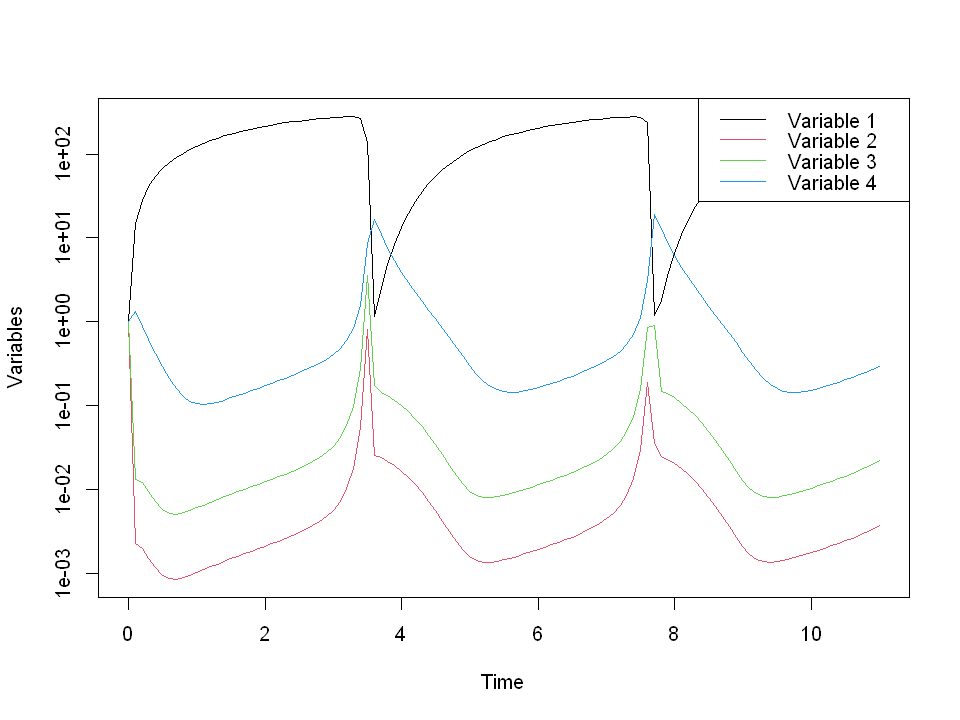

In [43]:
matplot(
  sol[,1], sol[,2:5],
  type = "l",
  lty = 1,
  log = "y",
  xlab = "Time",
  ylab = "Variables"
)

legend(
  "topright",
  legend = paste("Variable", 1:4),
  col = 1:4,
  lty = 1
)

In [44]:
# Continue simulation to observe stability
sol <-  deSolve::ode(y = as.numeric(sol[95,2:5]), times = seq(0,11,0.01), func = func_POSm4_list, 
                     parms=klin, knonlin=knonlin)

In [45]:
sol_for_plot <- as.data.frame(sol)

# rename columns for clarity
colnames(sol_for_plot) <- c("time", "S1", "S2", "S3", "S4")

# reshape to long format
sol_long <- sol_for_plot %>%
  pivot_longer(cols = S1:S4, names_to = "species", values_to = "value")

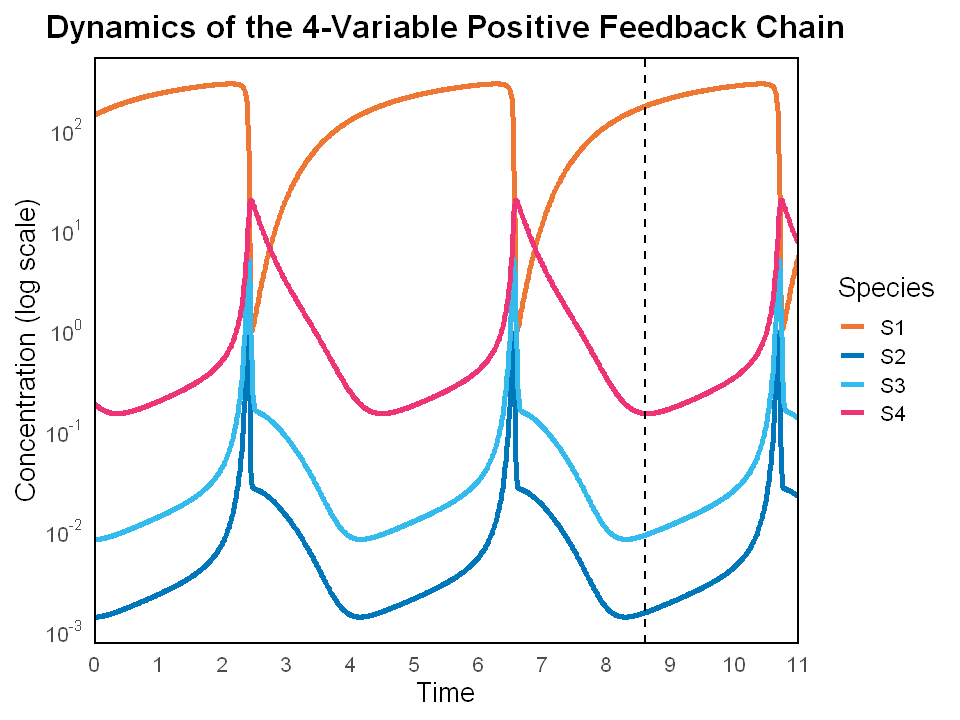

In [ ]:
options(repr.plot.width = 8, repr.plot.height = 6)
colors <- c(
  S1 = "#EE7733",
  S2 = "#0077BB",
  S3 = "#33BBEE",
  S4 = "#EE3377"
)

plot1 <- ggplot(sol_long, aes(x = time, y = value, colour = species)) +
  geom_line(size = 1.5) +
  ## vertical dashed line
  geom_vline(
    xintercept = perturbation_point,
    linetype = "dashed",
    colour = "black",
    linewidth = 0.7
  ) +
  scale_colour_manual(values = colors) + # scale_colour_brewer(palette = "Dark2") +
  scale_x_continuous(
    breaks = 0:11,
    minor_breaks = seq(0, 11, 0.5),
    limits = c(0, 11),
    expand = c(0, 0)
  ) +
  coord_cartesian(xlim = c(0, 11), clip = "on") +
  scale_y_log10(
    breaks = scales::trans_breaks("log10", function(x) 10^x),
    labels = scales::trans_format("log10", scales::math_format(10^.x))
  ) +              # log10 transformation
  labs(
    title = "Dynamics of the 4-Variable Positive Feedback Chain",
    x = "Time",
    y = "Concentration (log scale)",
    colour = "Species"
  ) +
  theme_minimal(base_size = 16) +
  theme(
    plot.title = element_text(face = "bold", hjust = 0.5),
    # panel.grid.minor = element_blank(),
    panel.grid = element_blank(),

    ## black outer box
    panel.border = element_rect(
      colour = "black",
      fill = NA,
      linewidth = 1.1
    )
  )

plot1
# ggsave("POSm4_plot.png", plot1, width = 10, height = 8, units = "in", dpi = 300)

### **2.4. Pertubation Analysis**

In [47]:
t0 <- 8.6          # perturbation time in original time axis
idx0 <- 86
cap <- 0.05        # window half-width (before/after), like Python cap_range
dt   <- 0.0001

In [48]:
s_star_pertubation_1 <- as.numeric(sol[855,2:5])
tpre = seq(-cap, 0, by = dt)
sol_pertubation_1_pre  <-  deSolve::ode(y = s_star_pertubation_1, times = tpre, func = func_POSm4_list, 
                     parms=klin, knonlin=knonlin)

s_star_pertubation_1 <- as.numeric(sol[860,2:5])
# Change the 4th position to 0.75
s_star_pertubation_1[4] <- 0.75

tpost <- seq(0, cap, by = dt)
sol_pertubation_1_post  <-  deSolve::ode(y = s_star_pertubation_1, times = tpost, func = func_POSm4_list, 
                     parms=klin, knonlin=knonlin)

In [49]:
t_all <- c(tpre, tpost)
y_all <- rbind(sol_pertubation_1_pre, sol_pertubation_1_post[, , drop = FALSE])

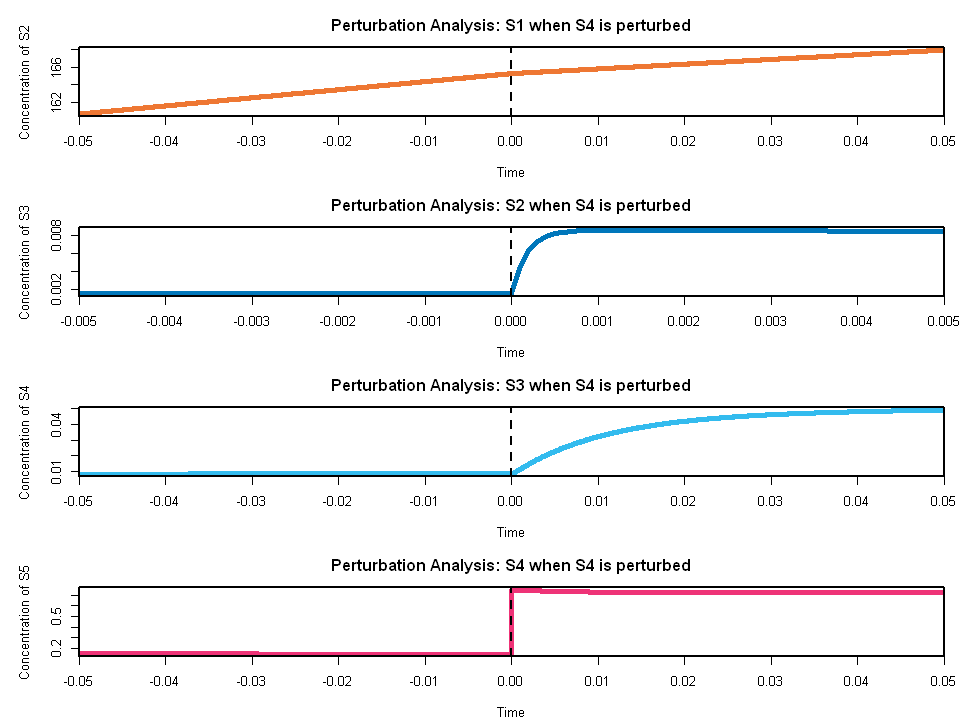

In [52]:
t_all <- c(tpre, tpost)
y_all <- rbind(sol_pertubation_1_pre, sol_pertubation_1_post[, , drop = FALSE])

# Plot: 4 stacked panels (base graphics)

# To save as PNG file, uncomment the following lines, and the dev.off() line at the end

# png(
#   filename = "model_1_perturbation.png",
#   width = 8, height = 8, units = "in",
#   res = 300          # DPI
# )

op <- par(mfrow = c(4,1), mar = c(4,5,3,1))
for (j in 2:5) {
  if (j==3) {
    xlim_vals <- c(-0.005, 0.005)
    ticks_seq <- seq(-0.005, 0.005, by = 0.001)
  } else {
    xlim_vals <- c(-0.05, 0.05)
    ticks_seq <- seq(-0.05, 0.05, by = 0.01)
  }
  plot(t_all, y_all[,j], type = "l", lwd = 4, col = colors[j-1],
       xlab = "Time", ylab = paste("Concentration of S", j, sep=""),
       xlim = xlim_vals, xaxt = "n", xaxs = "i",
       main = paste("Perturbation Analysis: S", j-1, " when S4 is perturbed", sep=""))
  axis(
    1,
    at = ticks_seq
  )
  abline(v = 0, lty = 2, lwd = 2)
  box(lwd = 2)   # black outer box
}

# dev.off()
par(op)

## **3. Additional features**

### **3.1. Add subject ID to make the loop result more comprehensible**

In [119]:
id_to_subject <- c(
  "S1", "S2", "S3", "S4"
)
names(id_to_subject) <- 1:4

In [120]:
df <- res_tab$loop_rep[[1]]

In [121]:
df$loop_subject <- lapply(
  df$loop,
  function(t) unname(id_to_subject[as.character(t)])
)


In [122]:
df

loop,length,sign,loop_subject
<I<list>>,<dbl>,<dbl>,<list>
"1, 1",1,-1,"S1, S1"
"2, 2",1,-1,"S2, S2"
"3, 3",1,-1,"S3, S3"
"4, 4",1,-1,"S4, S4"
"3, 4, 1,....",4,-1,"S3, S4, S1, S2, S3"
"3, 4, 2, 3",3,1,"S3, S4, S2, S3"


### **3.2. Represent regulation relationship from Jacobian matrix**

In [136]:
sign_J <- sign(j_matrix)
labs <- paste0("S", 1:nrow(sign_J))
rownames(sign_J) <- labs
colnames(sign_J) <- labs

regulation_info <- sign_J %>%
  as.data.frame() %>%
  mutate(from = rownames(.)) %>%
  pivot_longer(
    -from,
    names_to = "to",
    values_to = "regulation"
  ) %>%
  mutate(
    regulation_words = case_when(
      regulation == -1 ~ "inhibition (negative)",
      regulation ==  1 ~ "activation (positive)",
      TRUE             ~ "no regulation"
    )
  )
regulation_info[regulation_info$regulation != 0, ]

from,to,regulation,regulation_words
<chr>,<chr>,<dbl>,<chr>
S1,S1,-1,inhibition (negative)
S1,S4,-1,inhibition (negative)
S2,S1,1,activation (positive)
S2,S2,-1,inhibition (negative)
S2,S4,1,activation (positive)
S3,S2,1,activation (positive)
S3,S3,-1,inhibition (negative)
S4,S3,1,activation (positive)
S4,S4,-1,inhibition (negative)


### **3.3. Loop Summary in more detail**

In [161]:
df

loop,length,sign,loop_subject
<I<list>>,<dbl>,<dbl>,<list>
"1, 1",1,-1,"S1, S1"
"2, 2",1,-1,"S2, S2"
"3, 3",1,-1,"S3, S3"
"4, 4",1,-1,"S4, S4"
"3, 4, 1,....",4,-1,"S3, S4, S1, S2, S3"
"3, 4, 2, 3",3,1,"S3, S4, S2, S3"


In [162]:
split_by_len <- split(df, df$length)

loop_summary_extended <- data.frame(
  length = as.numeric(names(split_by_len)),
  num_loops = vapply(split_by_len, nrow, integer(1)),
  loops = I(lapply(split_by_len, function(x) x$loop_subject)),
  stringsAsFactors = FALSE
)

loop_summary_extended$num_loops_positive <- vapply(
  split_by_len,
  function(x) sum(x$sign > 0),
  integer(1)
)

loop_summary_extended$num_loops_negative <- vapply(
  split_by_len,
  function(x) sum(x$sign < 0),
  integer(1)
)

loop_summary_extended$loops_positive <- I(lapply(
  split_by_len,
  function(x) x$loop_subject[x$sign > 0]
))

loop_summary_extended$loops_negative <- I(lapply(
  split_by_len,
  function(x) x$loop_subject[x$sign < 0]
))

loop_summary_extended <- loop_summary_extended[
  order(loop_summary_extended$length),
  c("length","num_loops","num_loops_positive","num_loops_negative",
    "loops","loops_positive","loops_negative")
]

loop_summary_extended


,length,num_loops,num_loops_positive,num_loops_negative,loops,loops_positive,loops_negative
,<dbl>,<int>,<int>,<int>,<I<named list>>,<I<named list>>,<I<named list>>
1,1,4,0,4,"c(""S1"", ....",,"c(""S1"", ...."
3,3,1,1,0,"c(""S3"", ....","c(""S3"", ....",
4,4,1,0,1,"c(""S3"", ....",,"c(""S3"", ...."
